In [ ]:
# W2D2 — Feature Scaling & Selection

## Objective

Apply feature scaling techniques and feature selection methods to prepare numerical data for machine learning.

### Tasks
- StandardScaler
- MinMaxScaler
- RobustScaler
- Distribution comparison
- SelectKBest feature selection
- Top 5 feature identification
- Feature selection analysis

In [1]:
import pandas as pd

# Sample numerical dataset
data = pd.DataFrame({
    "Age": [20, 22, 25, 30, 35, 40, 45, 50],
    "Salary": [25000, 30000, 40000, 60000, 100000, 120000, 140000, 160000],
    "Experience": [1, 2, 3, 5, 8, 10, 15, 20],
    "Score": [55, 60, 65, 70, 80, 85, 90, 95],
    "Hours_Study": [2, 3, 4, 5, 6, 7, 8, 9],
    "Projects": [1, 1, 2, 3, 5, 6, 8, 10]
})

data

,Age,Salary,Experience,Score,Hours_Study,Projects
0,20,25000,1,55,2,1
1,22,30000,2,60,3,1
2,25,40000,3,65,4,2
3,30,60000,5,70,5,3
4,35,100000,8,80,6,5
5,40,120000,10,85,7,6
6,45,140000,15,90,8,8
7,50,160000,20,95,9,10


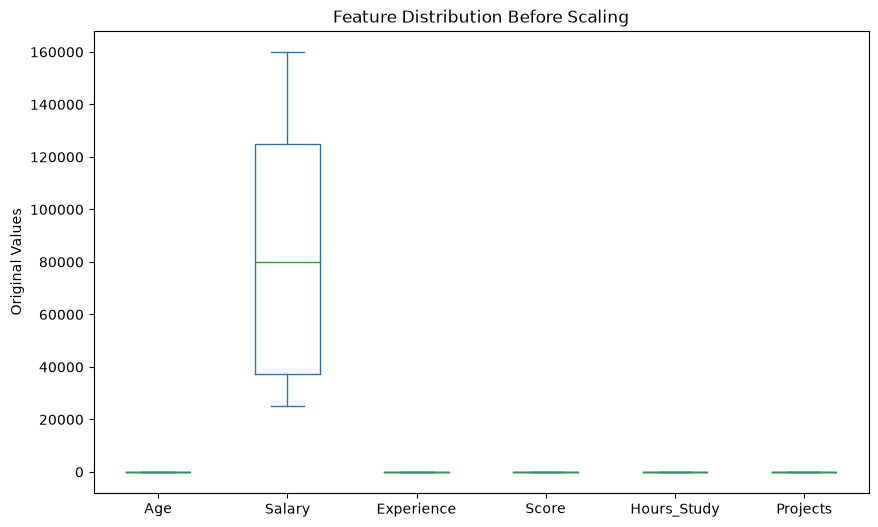

In [2]:
import matplotlib.pyplot as plt

# Distribution before scaling
data.plot(kind="box", figsize=(10, 6))
plt.title("Feature Distribution Before Scaling")
plt.ylabel("Original Values")
plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler

# Standard scaling
standard_scaler = StandardScaler()

standard_scaled = standard_scaler.fit_transform(data)

standard_df = pd.DataFrame(
    standard_scaled,
    columns=data.columns
)

standard_df


,Age,Salary,Experience,Score,Hours_Study,Projects
0,-1.299191,-1.206599,-1.113780,-1.460593,-1.527525,-1.120897
1,-1.104919,-1.104990,-0.954669,-1.095445,-1.091089,-1.120897
2,-0.813512,-0.901774,-0.795557,-0.730297,-0.654654,-0.800641
3,-0.327833,-0.495340,-0.477334,-0.365148,-0.218218,-0.480384
4,0.157846,0.317526,0.000000,0.365148,0.218218,0.160128
5,0.643524,0.723959,0.318223,0.730297,0.654654,0.480384
6,1.129203,1.130392,1.113780,1.095445,1.091089,1.120897
7,1.614882,1.536825,1.909337,1.460593,1.527525,1.761410


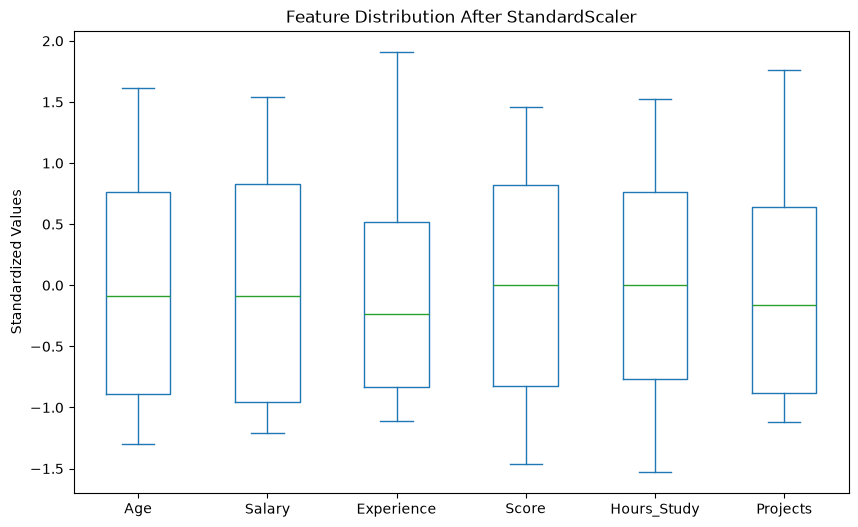

In [4]:


# Distribution after StandardScaler

standard_df.plot(kind="box", figsize=(10, 6))
plt.title("Feature Distribution After StandardScaler")
plt.ylabel("Standardized Values")
plt.show()

In [5]:
from sklearn.preprocessing import MinMaxScaler

# Min-Max scaling
minmax_scaler = MinMaxScaler()

minmax_scaled = minmax_scaler.fit_transform(data)

minmax_df = pd.DataFrame(
    minmax_scaled,
    columns=data.columns
)

minmax_df

,Age,Salary,Experience,Score,Hours_Study,Projects
0,0.000000,0.000000,0.000000,0.000,0.000000,0.000000
1,0.066667,0.037037,0.052632,0.125,0.142857,0.000000
2,0.166667,0.111111,0.105263,0.250,0.285714,0.111111
3,0.333333,0.259259,0.210526,0.375,0.428571,0.222222
4,0.500000,0.555556,0.368421,0.625,0.571429,0.444444
5,0.666667,0.703704,0.473684,0.750,0.714286,0.555556
6,0.833333,0.851852,0.736842,0.875,0.857143,0.777778
7,1.000000,1.000000,1.000000,1.000,1.000000,1.000000


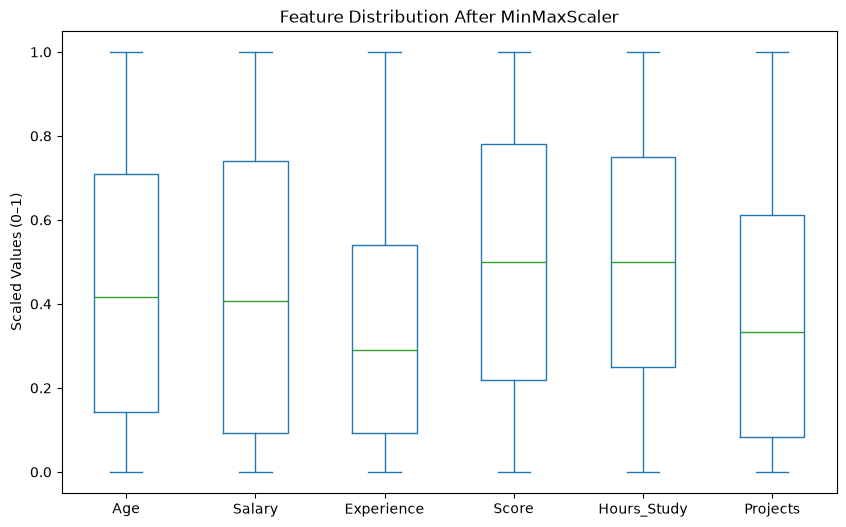

In [6]:
# Distribution after MinMaxScaler

minmax_df.plot(kind="box", figsize=(10, 6))
plt.title("Feature Distribution After MinMaxScaler")
plt.ylabel("Scaled Values (0–1)")
plt.show()


In [7]:
from sklearn.preprocessing import RobustScaler

# Robust scaling
robust_scaler = RobustScaler()

robust_scaled = robust_scaler.fit_transform(data)

robust_df = pd.DataFrame(
    robust_scaled,
    columns=data.columns
)

robust_df

,Age,Salary,Experience,Score,Hours_Study,Projects
0,-0.735294,-0.628571,-0.647059,-0.888889,-1.000000,-0.631579
1,-0.617647,-0.571429,-0.529412,-0.666667,-0.714286,-0.631579
2,-0.441176,-0.457143,-0.411765,-0.444444,-0.428571,-0.421053
3,-0.147059,-0.228571,-0.176471,-0.222222,-0.142857,-0.210526
4,0.147059,0.228571,0.176471,0.222222,0.142857,0.210526
5,0.441176,0.457143,0.411765,0.444444,0.428571,0.421053
6,0.735294,0.685714,1.000000,0.666667,0.714286,0.842105
7,1.029412,0.914286,1.588235,0.888889,1.000000,1.263158


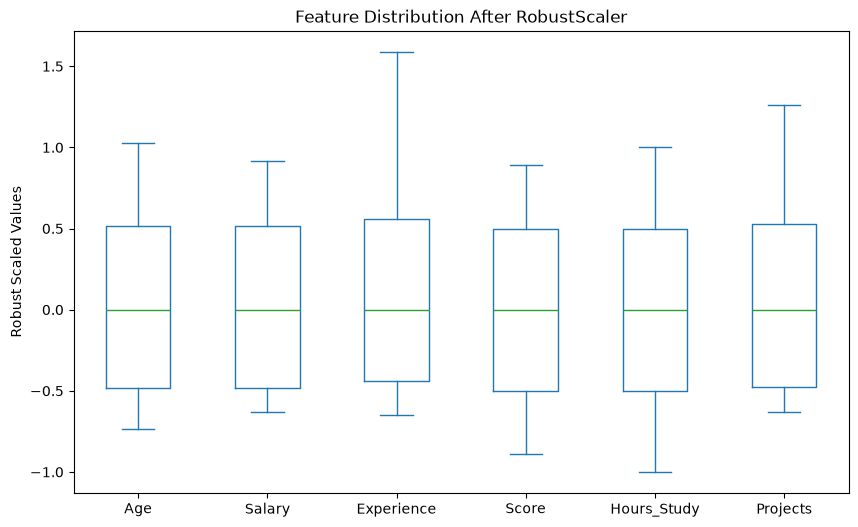

In [8]:
# Distribution after RobustScaler

robust_df.plot(kind="box", figsize=(10, 6))
plt.title("Feature Distribution After RobustScaler")
plt.ylabel("Robust Scaled Values")
plt.show()

In [9]:
from sklearn.feature_selection import SelectKBest, f_classif

# Target variable
target = [0, 0, 0, 1, 1, 1, 1, 1]

# Select top 5 features using ANOVA F-test
selector = SelectKBest(score_func=f_classif, k=5)

X_selected = selector.fit_transform(data, target)

selected_features = data.columns[selector.get_support()]

print("Top 5 Features:")
print(list(selected_features))

Top 5 Features:
['Age', 'Salary', 'Score', 'Hours_Study', 'Projects']


In [10]:
# Feature scores from SelectKBest

feature_scores = pd.DataFrame({
    "Feature": data.columns,
    "Score": selector.scores_
}).sort_values(by="Score", ascending=False)

feature_scores

,Feature,Score
3,Score,15.428571
4,Hours_Study,15.000000
0,Age,13.367703
1,Salary,13.254210
5,Projects,9.669643
2,Experience,7.240223


In [ ]:
## SelectKBest — Top 5 Features

SelectKBest with the ANOVA F-test was used to identify the five features with the strongest statistical relationship with the target variable.

### Top 5 Features

1. **Score — 15.43**
   - Has the highest score and shows the strongest relationship with the target.

2. **Hours_Study — 15.00**
   - Shows a strong relationship with the target and provides useful predictive information.

3. **Age — 13.37**
   - Provides useful information for distinguishing between the target classes.

4. **Salary — 13.25**
   - Shows a strong statistical relationship with the target.

5. **Projects — 9.67**
   - Provides useful information for predicting the target.

### Excluded Feature

**Experience — 7.24**

Experience had the lowest SelectKBest score, so it was not included in the top 5 features.

### Conclusion

SelectKBest helps reduce unnecessary features by selecting the features with the strongest statistical relationship with the target variable. This can simplify the dataset and help build more efficient machine learning models.

In [ ]:
# W2D2 Summary

## Completed Tasks

- ✓ Original feature distributions plotted
- ✓ StandardScaler applied
- ✓ StandardScaler distribution plotted
- ✓ MinMaxScaler applied
- ✓ MinMaxScaler distribution plotted
- ✓ RobustScaler applied
- ✓ RobustScaler distribution plotted
- ✓ Scaling methods compared
- ✓ SelectKBest applied using ANOVA F-test
- ✓ Top 5 features identified
- ✓ Feature scores calculated
- ✓ Reasons for selected features documented

## Top 5 Features

1. Score
2. Hours_Study
3. Age
4. Salary
5. Projects

## W2D2 Status

✓ COMPLETE